In [15]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt
import scipy as sp

In [16]:
# create transfer function

m = 60 # mass in kilograms
g = 9.81 # acceleration due to gravity, m/s^2
ta = 0.1598 #axial torque, kg * m
tr = ta # rotational torque, kg * m
fv = m*g # vertical force, N
fn = fv + m*g # normal force, N
jw = 0.21 # rotational inertia, kg * m^2
mu = 0.4 # kinetic coefficient of friction, unitless
ja = 6.434e-9 #moment of axial inertia, m^4
k = 3*0.11/0.05919 # spring constant, N/m
b = 2*np.sqrt(m*k) #dampening coefficient, Ns/m

A = np.array([[0, 1, 0, 0], 
              [-k/m, -b/m, 0, 0],
              [0, 0, 0, 1],
              [0, 0, -ta/jw, 0]])

B = np.array([[0], [1/m], [0], [1]])

C = np.array([1, 0, 1, 0])

D = np.array([0])

P = ct.ss(A, B, C, D)

print('A matrix:\n', P.A)
print('\nB matrix:\n', P.B)
print('\nC matrix:\n', P.C)
print('\nD matrix:\n', P.D)

A matrix:
 [[ 0.          1.          0.          0.        ]
 [-0.0929211  -0.60965925  0.          0.        ]
 [ 0.          0.          0.          1.        ]
 [ 0.          0.         -0.76095238  0.        ]]

B matrix:
 [[0.        ]
 [0.01666667]
 [0.        ]
 [1.        ]]

C matrix:
 [[1. 0. 1. 0.]]

D matrix:
 [[0.]]


In [17]:
cont = ct.ctrb(P.A, P.B)
print(cont)
print(np.linalg.matrix_rank(cont))

[[ 0.          0.01666667 -0.01016099  0.00464606]
 [ 0.01666667 -0.01016099  0.00464606 -0.00188834]
 [ 0.          1.          0.         -0.76095238]
 [ 1.          0.         -0.76095238  0.        ]]
4


In [18]:
# to transfer function
P_tf = ct.ss2tf(P)
print(P_tf)


          1.017 s^2 + 0.6097 s + 0.1056
--------------------------------------------------
s^4 + 0.6097 s^3 + 0.8539 s^2 + 0.4639 s + 0.07071



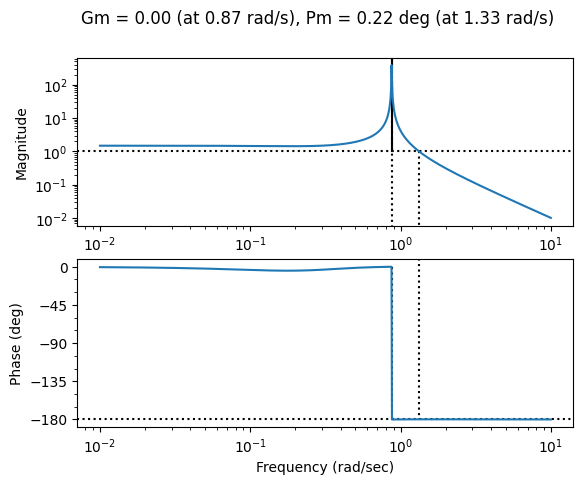

In [19]:
mag, phase, omega = ct.bode_plot(P_tf, margins=True)

(array([[-3.04829627e-01-4.09461346e-09j, -3.04829627e-01+4.09461346e-09j,
          0.00000000e+00-8.72325846e-01j,  0.00000000e+00+8.72325846e-01j],
        [-3.04829627e-01-4.09461346e-09j, -3.04829627e-01+4.09461346e-09j,
          0.00000000e+00-8.72325846e-01j,  0.00000000e+00+8.72325846e-01j],
        [-3.04829538e-01-7.71376471e-03j, -3.04829538e-01+7.71376471e-03j,
         -8.88247931e-08-8.74378463e-01j, -8.88247931e-08+8.74378463e-01j],
        ...,
        [-2.99904818e-01-1.17780599e-01j, -2.99904818e-01+1.17780599e-01j,
         -4.92480950e-03-1.07260114e+01j, -4.92480950e-03+1.07260114e+01j],
        [-2.99839730e-01-1.18164386e-01j, -2.99839730e-01+1.18164386e-01j,
         -4.98989736e-03-3.38197568e+01j, -4.98989736e-03+3.38197568e+01j],
        [-2.99833152e-01-1.18202961e-01j, -2.99833152e-01+1.18202961e-01j,
         -4.99647533e-03-1.06916152e+02j, -4.99647533e-03+1.06916152e+02j]]),
 array([0.00000000e+00, 0.00000000e+00, 3.58512030e-03, 7.17024059e-03,
       

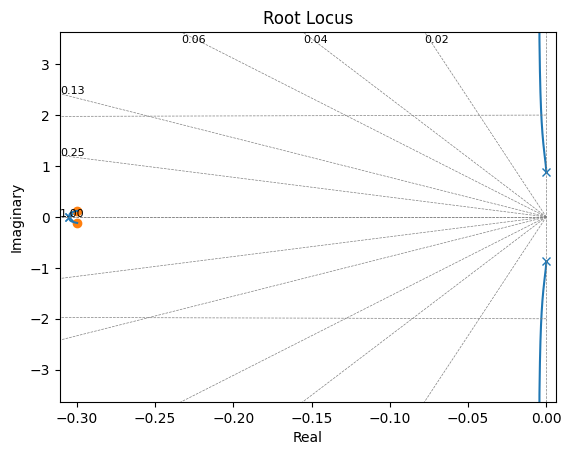

In [20]:
ct.root_locus(P_tf)

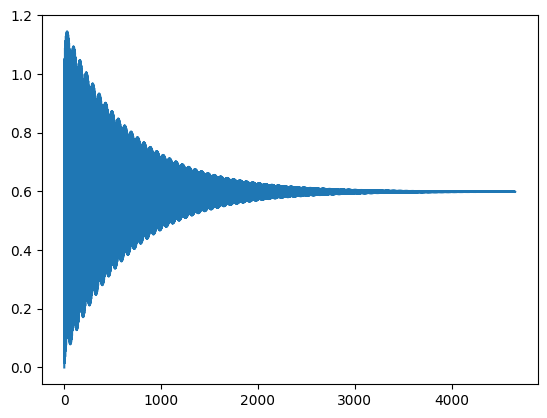

In [21]:
K_unity = 1
L = K_unity * P_tf
T = L / (1+L)

t, y = ct.step_response(T)
plt.plot(t, y)

In [8]:
poles = ct.poles(P_tf)
zeroes = ct.zeros(P_tf)

print("Poles: ", poles)
print("Zeroes: ", zeroes)

Poles:  [-0.30482963+0.j -0.30482963+0.j]
Zeroes:  [1.50119988e+14+0.j]


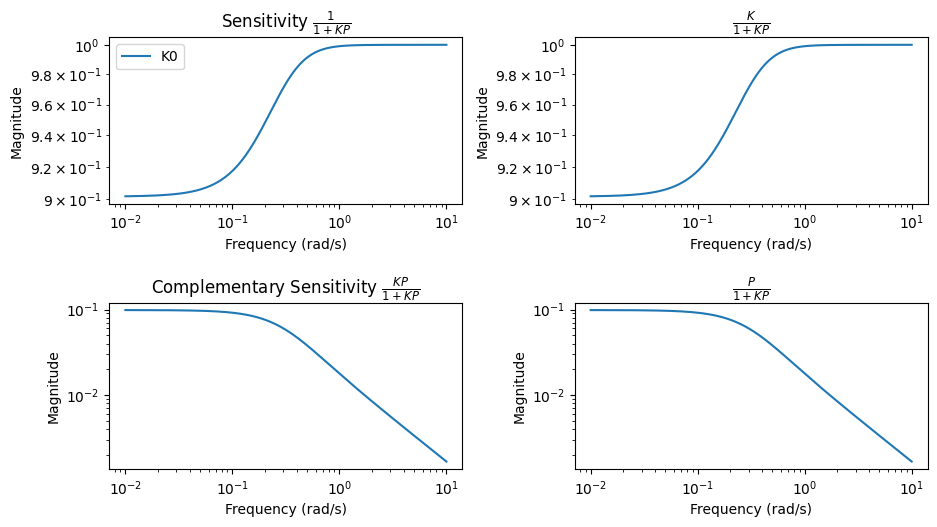

In [17]:
def plot_gang_of_four(P,K):
    num_sys = len(K)
    fig, ax = plt.subplots(2,2, figsize=(10,6))
    fig.tight_layout(pad=5.0)
    for ii in range(num_sys):
        T = P*K[ii]/(1+P*K[ii])
        S = 1/(1+P*K[ii])
        SK = K[ii]*S
        SP = P*S
        mag_S, phase_S, w_S = ct.bode_plot(S,plot=False)
        mag_T, phase_T, w_T = ct.bode_plot(T,plot=False)
        mag_SK, phase_SK, w_SK = ct.bode_plot(SK,plot=False)
        mag_SP, phase_SP, w_SP = ct.bode_plot(SP,plot=False)
        label_str = 'K' + str(ii)
        ax[0,0].loglog(w_S,mag_S, label=label_str)
        ax[0,0].set_title(r'Sensitivity $\frac{1}{1+KP}$')
        ax[0,0].legend()
        ax[0,0].set_xlabel('Frequency (rad/s)')
        ax[0,0].set_ylabel('Magnitude')
        ax[1,0].loglog(w_T,mag_T)
        ax[1,0].set_title(r'Complementary Sensitivity $\frac{KP}{1+KP}$')
        ax[1,0].set_xlabel('Frequency (rad/s)')
        ax[1,0].set_ylabel('Magnitude')
        ax[0,1].loglog(w_SK,mag_SK)
        ax[0,1].set_title(r'$\frac{K}{1+KP}$')
        ax[0,1].set_xlabel('Frequency (rad/s)')
        ax[0,1].set_ylabel('Magnitude')
        ax[1,1].loglog(w_SP,mag_SP)
        ax[1,1].set_title(r'$\frac{P}{1+KP}$')
        ax[1,1].set_xlabel('Frequency (rad/s)')
        ax[1,1].set_ylabel('Magnitude')
    return fig, ax
K_arr = [ ]
K_arr.append(ct.tf([1], [1]))
#K_arr.append(K)
fig, ax = plot_gang_of_four(P_tf,K_arr) #P is the plant, K is your controller

Wonderful! Now try adding in lead/lag controllers to fix that phase margin